# S6-1 FRAと金利スワップのプライシング

## 学習目標

- FRA を「借りて貸す」複製で組み、無裁定フォワードレートを自力で導出できる
- 金利スワップを固定債と変動債の交換として捉え、変動レッグが単利フォワードで
  テレスコープして $1 - P(t_n)$ になる仕組みを説明できる
- パースワップレートが $\dfrac{1 - P(t_n)}{\text{annuity}}$ に落ちる式を導き、
  スケジュール生成からキャッシュフロー割引まで評価エンジンを自作できる
- 割引カーブと推計カーブを分けるマルチカーブ評価と、レート感応度 DV01 を計算できる
- 自作エンジンを `bondlab.pricing.par_swap_rate` / `swap_annuity` と、さらに
  QuantLib の `VanillaSwap` と突合して一致を確認できる

## 実務での位置づけ（ファンドはどう稼ぐか）

金利スワップは銀行レートデスクの中核商品です。ディーラーはパースワップレートに対して継続的にビッド・オファーの両面クォートを出し、顧客（事業法人・年金・他行）の受け・払いニーズ（RFQ）に約定して、そのスプレッドを収益にします。約定のたびにデスクは反対サイドの在庫を抱えるので、ここで計算した DV01 が効いてきます。10年スワップを1本受けたら、その $\partial V/\partial y$ を国債先物や別年限のスワップで相殺し、レート水準そのもののリスクを落として「スプレッドだけ抜く」のがマーケットメイクの基本動作です。

相対価値（RV）の視点では、スワップは割安・割高なキャッシュフローを組み替える道具になります。国債利回りとスワップレートの差（スワップスプレッド）、異なる年限間のカーブの形（スティープナー／フラットナー／バタフライ）、あるいはアセットスワップにした社債のスプレッドなどが取引対象です。いずれも方向性リスクを DV01 中立・キーレート中立でヘッジし、ヘッジ後に残るキャリーとゆがみの収束をアルファとして取りにいきます。本 notebook で割引カーブと推計カーブを分けたのは、この RV の損益がベーシス（担保・テナー・通貨のカーブ差）に強く依存し、シングルカーブでは損益が正しく測れないためです。

クオンツの担当という観点では、ここで自作したスケジュール生成・キャッシュフロー割引・パーレート逆算・DV01 は、フロントのプライシングライブラリそのものです。カーブ構築（S2）で作った割引係数を入力に、評価とヘッジ比率を吐き出すこのエンジンが、デスクの値付けとリスク管理の起点になります。`bondlab` や QuantLib と機械精度で突合するのは、モデルバリデーション（独立検証）が要求する再現性の担保でもあります。


## 理論

### FRA の複製論法（借りて貸す）

フォワードレート・アグリーメント（FRA, forward rate agreement）は、将来の区間
$[t_1, t_2]$ に適用する金利を今日固定する契約です。適用金利 $L(t_1, t_2)$ が
期日に判明する変動レートで、契約時に決めた固定レート $K$ との差を精算します。

このフォワードレートは、割引カーブだけから無裁定で決まります。今日、次の二つの
取引を同時に行います。

- $t_1$ 満期の割引債を1単位分**借りて**売り、現金 $P(t_1)$ を受け取る
- その $P(t_1)$ で $t_2$ 満期の割引債を $P(t_1)/P(t_2)$ 単位**買う（貸す）**

今日の正味キャッシュフローはゼロです。$t_1$ で借りた債券の償還 1 を返し、$t_2$ で
買った債券から $P(t_1)/P(t_2)$ を受け取ります。つまり「$t_1$ に 1 を払い、$t_2$ に
$P(t_1)/P(t_2)$ を受け取る」ポジションを、コストゼロで合成できます。これは
$t_1$ に 1 を貸して $t_2$ に元利 $P(t_1)/P(t_2)$ で回収するのと同値であり、
区間の単利フォワードレート $F$ は

$$
1 + F \,\tau = \frac{P(t_1)}{P(t_2)}, \qquad
F(t_1, t_2) = \frac{1}{\tau}\left(\frac{P(t_1)}{P(t_2)} - 1\right)
$$

で定まります。ここで $\tau = t_2 - t_1$ は区間の年数、$P(t)$ は今日から $t$ までの
割引係数です。複製ポートフォリオが確定した将来キャッシュフローを作るため、$F$ は
期待値ではなくカーブから一意に決まります。連続複利フォワード
$f = \ln(P(t_1)/P(t_2))/\tau$ とは別物で、スワップ慣行では上の単利表現を使います。

### スワップ＝債券の交換

固定金利を払い変動金利を受け取るペイヤースワップは、**固定利付債を売って変動利付債を
買う**ポジションと同値です。想定元本 $N$、固定レート $c$、支払時点
$t_1 < t_2 < \dots < t_n$、各区間 $\tau_i = t_i - t_{i-1}$ とすると、

- 固定レッグの現在価値： $V_{\text{fix}} = N\, c \sum_{i=1}^n \tau_i P(t_i)$
- 変動レッグの現在価値： $V_{\text{flt}} = N \sum_{i=1}^n \tau_i P(t_i) F_i$

変動レートは各区間のフォワード $F_i = \tau_i^{-1}\!\left(P(t_{i-1})/P(t_i) - 1\right)$ で
評価します（S6-1 では受渡時点＝観測区間末とする標準的な設定）。

### パースワップレートとテレスコープ

シングルカーブ（割引＝推計が同一カーブ）では、変動レッグに $F_i$ を代入すると

$$
V_{\text{flt}} = N \sum_{i=1}^n \tau_i P(t_i)\,
\frac{1}{\tau_i}\!\left(\frac{P(t_{i-1})}{P(t_i)} - 1\right)
= N \sum_{i=1}^n \bigl(P(t_{i-1}) - P(t_i)\bigr)
= N\bigl(P(t_0) - P(t_n)\bigr)
$$

と隣接項が打ち消し合い（テレスコープ）、$P(t_0)=1$ なので $V_{\text{flt}} = N(1 - P(t_n))$
に潰れます。変動レッグは「今日 1 を受け取り、満期に $P(t_n)$ を返す」floater と同じ
価値です。スワップの価値がゼロになる固定レート、すなわちパースワップレート
（par swap rate）は $V_{\text{fix}} = V_{\text{flt}}$ より

$$
c^\ast = \frac{1 - P(t_n)}{\sum_{i=1}^n \tau_i P(t_i)}
       = \frac{1 - P(t_n)}{A}, \qquad
A \equiv \sum_{i=1}^n \tau_i P(t_i)
$$

となります。分母 $A$ をアニュイティ（annuity, 固定レッグの PV01 の元）と呼びます。

### マルチカーブでの評価

金融危機以降、割引と金利推計を別カーブで行うのが標準です。担保付き取引の割引は
OIS カーブ $P^{d}$、変動レートの推計は対象インデックスのカーブ $P^{p}$ を使います。
このときテレスコープは成立せず、レッグを分けて評価します。

$$
V_{\text{flt}} = N \sum_{i=1}^n \tau_i\, P^{d}(t_i)\, F_i^{p},
\qquad F_i^{p} = \frac{1}{\tau_i}\!\left(\frac{P^{p}(t_{i-1})}{P^{p}(t_i)} - 1\right)
$$

$$
c^\ast = \frac{\sum_{i=1}^n \tau_i\, P^{d}(t_i)\, F_i^{p}}
              {\sum_{i=1}^n \tau_i\, P^{d}(t_i)}
$$

フォワード $F_i^{p}$ は推計カーブから、割引は $P^{d}$ から取ります。$P^{d}=P^{p}$ の
特別な場合にシングルカーブの式へ戻ります。

### DV01

DV01（dollar value of a basis point）は、金利が 1bp（$0.0001$）動いたときのスワップ
価値の変化額です。パーで約定したペイヤースワップの価値は、固定レートを $c^\ast$ から
$c$ に動かすと $V = N(c - c^\ast)\,A$ なので、レートに対する感応度はアニュイティに
比例します。

$$
\text{DV01} = \left|\frac{\partial V}{\partial c}\right| \times 10^{-4}
            = N \cdot A \cdot 10^{-4}
$$

アニュイティ $A$ が固定レッグの現在価値加重の年数和なので、年限が伸びるほど
DV01 は増えます。カーブ全体を 1bp 平行移動させた感応度は、割引係数の変化も含むため
上式と厳密には一致せず、数値差分で測るのが実務的です。

**数値例**：フラット3%カーブの割引係数 $P(t_1)=0.9709,\ P(t_2)=0.9426$、$\tau=1$ を FRA フォワードに代入すると $F=\dfrac{1}{1}\left(\dfrac{0.9709}{0.9426}-1\right)=0.0300=3.00\%$ となります。

**数値例**：同カーブの5年スワップでは $1-P(t_5)=1-0.8626=0.1374$、アニュイティ $A=\sum_{i=1}^{5}\tau_i P(t_i)=4.5797$ なので、パースワップレートは $c^\ast=\dfrac{0.1374}{4.5797}=0.0300=3.00\%$ とパー金利に一致します（テレスコープ）。

**数値例**：想定元本 $N=10^{8}$ 円（1億円）、割引カーブ（OIS）の $A(5y)=4.6768$ のとき、DV01 $=N\cdot A\cdot 10^{-4}=10^{8}\times 4.6768\times 10^{-4}\approx 46{,}768$ 円/bp です。


## スクラッチ実装

スワップ評価エンジンを numpy で組みます。流れは「スケジュール生成 → 各時点の
キャッシュフロー割引 → 固定/変動レッグの合算」です。実装後に
`bondlab.pricing.par_swap_rate` / `swap_annuity` と突合します。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `swap_schedule(maturity, frequency)` | 満期(年), 年間支払回数 | 支払時点の配列 | 等間隔グリッドを生成 |
| `accruals(times)` | 支払時点の配列 | 各区間の年数 $\tau_i$ | 隣接差分（先頭は 0 起点） |
| `annuity(disc, times)` | 割引カーブ, 支払時点 | アニュイティ $A$ | $\sum \tau_i P(t_i)$ |
| `fixed_leg_pv(disc, times, c, notional)` | 割引カーブ, 支払時点, 固定レート, 元本 | 固定レッグ PV | $Nc\sum\tau_i P(t_i)$ |
| `simple_forwards(proj, times)` | 推計カーブ, 支払時点 | 単利フォワード配列 $F_i$ | $(P_{i-1}/P_i-1)/\tau_i$ |
| `float_leg_pv(disc, proj, times, notional)` | 割引カーブ, 推計カーブ, 支払時点, 元本 | 変動レッグ PV | $N\sum\tau_i P^d_i F^p_i$ |
| `swap_npv(disc, proj, times, c, notional, payer)` | 割引/推計カーブ, 支払時点, 固定レート, 元本, ペイヤーか | スワップ NPV | 変動−固定（ペイヤー） |
| `par_rate(disc, proj, times)` | 割引/推計カーブ, 支払時点 | パースワップレート | NPV=0 の固定レート |
| `dv01_parallel(disc, proj, times, c, notional)` | 割引/推計カーブ, 支払時点, 固定レート, 元本 | DV01 | カーブ 1bp 平行移動の数値差分 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.font_manager as _fm
for _f in ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Noto Sans JP", "TakaoPGothic", "IPAPGothic"]:
    if any(_f == _n.name for _n in _fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
import bondlab
from bondlab.curve import DiscountCurve, bootstrap_par
from bondlab.pricing import par_swap_rate, swap_annuity

np.random.seed(0)
print("bondlab version:", bondlab.__version__)


def swap_schedule(maturity, frequency):
    """満期 maturity（年）まで、年 frequency 回払いの支払時点を等間隔で生成する。"""
    n = int(round(maturity * frequency))
    return np.arange(1, n + 1, dtype=float) / frequency


def accruals(times):
    """支払時点の配列から各区間の年数 τ_i を返す。t_0 = 0 を起点に差分を取る。"""
    times = np.asarray(times, dtype=float)
    return np.diff(np.concatenate([[0.0], times]))


def annuity(disc, times):
    """アニュイティ A = Σ τ_i P(t_i)。固定レッグ 1 単位クーポンの現在価値。"""
    times = np.asarray(times, dtype=float)
    return float(np.sum(accruals(times) * disc.discount(times)))


def fixed_leg_pv(disc, times, c, notional=1.0):
    """固定レッグ PV = N c Σ τ_i P(t_i)。"""
    return notional * c * annuity(disc, times)


def simple_forwards(proj, times):
    """各区間の単利フォワード F_i = (P(t_{i-1})/P(t_i) - 1)/τ_i。"""
    times = np.asarray(times, dtype=float)
    t_all = np.concatenate([[0.0], times])
    tau = np.diff(t_all)
    p_prev = proj.discount(t_all[:-1])
    p_curr = proj.discount(times)
    return (p_prev / p_curr - 1.0) / tau


def float_leg_pv(disc, proj, times, notional=1.0):
    """変動レッグ PV = N Σ τ_i P^d(t_i) F_i^p。割引は disc、フォワードは proj。"""
    times = np.asarray(times, dtype=float)
    tau = accruals(times)
    disc_df = disc.discount(times)
    fwd = simple_forwards(proj, times)
    return notional * float(np.sum(tau * disc_df * fwd))


def swap_npv(disc, proj, times, c, notional=1.0, payer=True):
    """スワップ NPV。ペイヤー（固定払い）は 変動 − 固定、レシーバーは符号反転。"""
    flt = float_leg_pv(disc, proj, times, notional)
    fix = fixed_leg_pv(disc, times, c, notional)
    npv = flt - fix
    return npv if payer else -npv


def par_rate(disc, proj, times):
    """NPV=0 の固定レート。変動レッグ PV をアニュイティで割る。"""
    flt = float_leg_pv(disc, proj, times, notional=1.0)
    return flt / annuity(disc, times)


def dv01_parallel(disc, proj, times, c, notional=1.0, payer=True):
    """カーブ全体を 1bp 平行移動させたときの NPV 変化額（数値差分）。

    ゼロレートに ±0.5bp を加えた割引・推計カーブを作り、中央差分で感応度を測る。
    """
    bump = 1e-4

    def shifted(curve, d):
        z = curve.zero_rate(curve.times[1:])
        dfs = np.exp(-(z + d) * curve.times[1:])
        return DiscountCurve(curve.times[1:], dfs, interp=curve.interp)

    up = swap_npv(shifted(disc, +0.5 * bump), shifted(proj, +0.5 * bump), times, c, notional, payer)
    dn = swap_npv(shifted(disc, -0.5 * bump), shifted(proj, -0.5 * bump), times, c, notional, payer)
    return abs(up - dn)

bondlab version: 0.0.1


### bondlab との突合

フラットな年1回 3% パーカーブを剥ぎ取り、5年スワップで自作エンジンと bondlab の
関数が一致すること、パーレートが厳密に 3% になること（テレスコープ）を確認します。

In [2]:
tenors = [1, 2, 3, 4, 5]
flat_curve = bootstrap_par(tenors, [0.03] * 5, frequency=1)
times5 = swap_schedule(5.0, frequency=1)

my_ann = annuity(flat_curve, times5)
lib_ann = swap_annuity(flat_curve, times5)
my_par = par_rate(flat_curve, flat_curve, times5)
lib_par = par_swap_rate(flat_curve, flat_curve, times5)

print(f"アニュイティ  自作={my_ann:.10f}  bondlab={lib_ann:.10f}")
print(f"パーレート    自作={my_par:.10f}  bondlab={lib_par:.10f}")
print(f"テレスコープ検算 (1-P(5))/A = {(1 - flat_curve.discount(5.0)) / my_ann:.10f}")

assert abs(my_ann - lib_ann) < 1e-12
assert abs(my_par - lib_par) < 1e-12
assert abs(my_par - 0.03) < 1e-12
print("突合を通過しました（フラット3%で par == 0.03）")

アニュイティ  自作=4.5797071872  bondlab=4.5797071872
パーレート    自作=0.0300000000  bondlab=0.0300000000
テレスコープ検算 (1-P(5))/A = 0.0300000000
突合を通過しました（フラット3%で par == 0.03）


傾きのあるカーブでも一致するか確認します。パーで約定したスワップの NPV は
ゼロになるはずです。

In [3]:
slope_par = [0.020, 0.025, 0.028, 0.030, 0.031]
slope_curve = bootstrap_par(tenors, slope_par, frequency=1)

my_par_s = par_rate(slope_curve, slope_curve, times5)
lib_par_s = par_swap_rate(slope_curve, slope_curve, times5)
npv_at_par = swap_npv(slope_curve, slope_curve, times5, my_par_s, notional=1.0)

print(f"パーレート（傾きあり） 自作={my_par_s:.10f}  bondlab={lib_par_s:.10f}")
print(f"パー約定 NPV = {npv_at_par:.3e}")

assert abs(my_par_s - lib_par_s) < 1e-12
assert abs(npv_at_par) < 1e-12
print("突合を通過しました")

パーレート（傾きあり） 自作=0.0310000000  bondlab=0.0310000000
パー約定 NPV = 0.000e+00
突合を通過しました


## QuantLib検証

QuantLib の `VanillaSwap` と、フェアレート・NPV を突合します。自作カーブは
支払時点を整数年に取っているため、QuantLib 側も日数計算を 30/360、支払日を
各年 5/15 にそろえ、区間の年数を厳密に 1.0 にします。こうすると評価枠組みが
一致し、機械精度で照合できます。

In [4]:
import QuantLib as ql

print("QuantLib version:", ql.__version__)

today = ql.Date(15, 5, 2026)
ql.Settings.instance().evaluationDate = today
day_count = ql.Thirty360(ql.Thirty360.BondBasis)


def to_ql_handle(curve, times):
    """bondlab の DiscountCurve を QuantLib の DiscountCurve ハンドルへ変換する。"""
    dates = [today] + [ql.Date(15, 5, 2026 + int(t)) for t in times]
    dfs = [1.0] + [curve.discount(float(t)) for t in times]
    ql_curve = ql.DiscountCurve(dates, dfs, day_count)
    ql_curve.enableExtrapolation()
    return ql.YieldTermStructureHandle(ql_curve)


def ql_vanilla_swap(disc_handle, proj_handle, fixed_rate, maturity_years):
    """QuantLib の年1回ペイヤー VanillaSwap を組み、割引エンジンを設定して返す。"""
    maturity = ql.Date(15, 5, 2026 + maturity_years)
    schedule = ql.Schedule(
        today, maturity, ql.Period(ql.Annual), ql.NullCalendar(),
        ql.Unadjusted, ql.Unadjusted, ql.DateGeneration.Forward, False,
    )
    index = ql.IborIndex(
        "SCRATCH", ql.Period(ql.Annual), 0, ql.USDCurrency(),
        ql.NullCalendar(), ql.Unadjusted, False, day_count, proj_handle,
    )
    swap = ql.VanillaSwap(
        ql.VanillaSwap.Payer, 1.0, schedule, fixed_rate, day_count,
        schedule, index, 0.0, day_count,
    )
    swap.setPricingEngine(ql.DiscountingSwapEngine(disc_handle))
    return swap


# シングルカーブ（傾きあり）での突合
handle_s = to_ql_handle(slope_curve, times5)
swap_s = ql_vanilla_swap(handle_s, handle_s, my_par_s, 5)

print("--- シングルカーブ 5年 ---")
print(f"自作パーレート   = {my_par_s:.12f}")
print(f"QL フェアレート  = {swap_s.fairRate():.12f}")
print(f"QL NPV（パー約定）= {swap_s.NPV():.3e}")

assert abs(my_par_s - swap_s.fairRate()) < 1e-10
assert abs(swap_s.NPV()) < 1e-8

QuantLib version: 1.42.1
--- シングルカーブ 5年 ---
自作パーレート   = 0.031000000000
QL フェアレート  = 0.031000000000
QL NPV（パー約定）= 4.163e-16


割引と推計を別カーブにしたマルチカーブでも、フェアレートが一致することを確認します。

In [5]:
ois_par = [0.018, 0.022, 0.025, 0.027, 0.028]
proj_par = [0.020, 0.025, 0.028, 0.030, 0.031]
disc_curve = bootstrap_par(tenors, ois_par, frequency=1)
proj_curve = bootstrap_par(tenors, proj_par, frequency=1)

my_par_mc = par_rate(disc_curve, proj_curve, times5)
lib_par_mc = par_swap_rate(disc_curve, proj_curve, times5)

handle_d = to_ql_handle(disc_curve, times5)
handle_p = to_ql_handle(proj_curve, times5)
swap_mc = ql_vanilla_swap(handle_d, handle_p, my_par_mc, 5)

print("--- マルチカーブ 5年（割引=OIS, 推計=別カーブ）---")
print(f"自作パーレート   = {my_par_mc:.12f}")
print(f"bondlab パーレート= {lib_par_mc:.12f}")
print(f"QL フェアレート  = {swap_mc.fairRate():.12f}")

assert abs(my_par_mc - lib_par_mc) < 1e-12
assert abs(my_par_mc - swap_mc.fairRate()) < 1e-10
print("QuantLib と機械精度で一致しました")

--- マルチカーブ 5年（割引=OIS, 推計=別カーブ）---
自作パーレート   = 0.031024458532
bondlab パーレート= 0.031024458532
QL フェアレート  = 0.031024458532
QuantLib と機械精度で一致しました


## 実データ適用

`bootstrap_par` で合成のマルチカーブ（割引＝OIS、推計＝別カーブ）を作り、5年
パースワップを約定します。そのうえで、市場が全く動かなくても時間の経過だけで
生じる損益（キャリー＋ロールダウン）を計算します。

### ロールダウンの考え方

パーで約定した瞬間、スワップの価値はゼロです。1年後、カーブの形が今日のまま
変わらないと仮定します。当初の 5 年スワップは残存 4 年になり、当初の固定レート
$c^\ast_{5y}$ を、いまの 4 年パーレート $c^\ast_{4y}$ と比べることになります。上向き
カーブでは $c^\ast_{5y} > c^\ast_{4y}$ なので、固定払いのペイヤーは「市場より高い固定を
払い続ける」不利を負い、価値はマイナスへ動きます（ロールダウンで損）。逆に固定
受けのレシーバーは同額のプラスを得ます。これが「何もしなくても発生する PnL」です。

In [6]:
years = [1, 2, 3, 4, 5, 6, 7]
ois_rates = [0.015, 0.019, 0.022, 0.024, 0.025, 0.026, 0.0265]
proj_rates = [0.018, 0.023, 0.026, 0.028, 0.029, 0.0295, 0.030]
disc_full = bootstrap_par(years, ois_rates, frequency=1)
proj_full = bootstrap_par(years, proj_rates, frequency=1)

notional = 100_000_000.0  # 1億円
sched_5y = swap_schedule(5.0, frequency=1)
c_star_5y = par_rate(disc_full, proj_full, sched_5y)
print(f"約定：5年ペイヤースワップ  固定レート c* = {c_star_5y:.6%}")
print(f"約定時 NPV = {swap_npv(disc_full, proj_full, sched_5y, c_star_5y, notional):.2f} 円")

# 1年経過。カーブは不変とし、残存4年のスワップを「今日のカーブ」で評価し直す。
# 時点を 1 年前倒し（当初 t=2..5 が経過後 t=1..4 に対応）して評価する。
roll_times = swap_schedule(4.0, frequency=1)
c_star_4y = par_rate(disc_full, proj_full, roll_times)
npv_after_1y = swap_npv(disc_full, proj_full, roll_times, c_star_5y, notional, payer=True)

print(f"\n1年後（カーブ不変）：残存4年パーレート c*_4y = {c_star_4y:.6%}")
print(f"当初固定 {c_star_5y:.6%} を払い続けるペイヤーの NPV = {npv_after_1y:,.0f} 円")
print(f"ロールダウン PnL（ペイヤー、1年）= {npv_after_1y:,.0f} 円")

約定：5年ペイヤースワップ  固定レート c* = 2.903180%
約定時 NPV = 0.00 円

1年後（カーブ不変）：残存4年パーレート c*_4y = 2.802894%
当初固定 2.903180% を払い続けるペイヤーの NPV = -380,454 円
ロールダウン PnL（ペイヤー、1年）= -380,454 円


残存年限を 5→4→3→2→1 と進め、当初固定を払い続けるペイヤーの価値が、上向き
カーブ上をどう滑り落ちるかを描きます。各点は「その残存年限のパーレートと当初固定
の差 × アニュイティ × 元本」です。

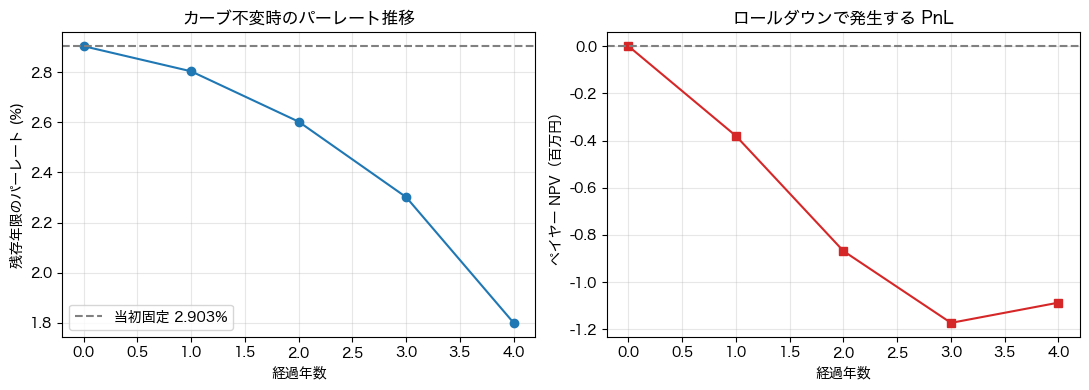

上向きカーブでは、固定払いペイヤーの価値は時間とともにマイナスへ滑る。
ポジションは動かしていないのに、カーブを転がり落ちる分だけ損益が出る。


In [7]:
remaining = [5, 4, 3, 2, 1]
npv_path = []
par_path = []
for m in remaining:
    tt = swap_schedule(float(m), frequency=1)
    par_path.append(par_rate(disc_full, proj_full, tt))
    npv_path.append(swap_npv(disc_full, proj_full, tt, c_star_5y, notional, payer=True))

elapsed = [5 - m for m in remaining]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(elapsed, np.array(par_path) * 100, "o-", color="#1f77b4")
ax1.axhline(c_star_5y * 100, ls="--", color="gray", label=f"当初固定 {c_star_5y:.3%}")
ax1.set_xlabel("経過年数")
ax1.set_ylabel("残存年限のパーレート (%)")
ax1.set_title("カーブ不変時のパーレート推移")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(elapsed, np.array(npv_path) / 1e6, "s-", color="#d62728")
ax2.axhline(0.0, ls="--", color="gray")
ax2.set_xlabel("経過年数")
ax2.set_ylabel("ペイヤー NPV（百万円）")
ax2.set_title("ロールダウンで発生する PnL")
ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("上向きカーブでは、固定払いペイヤーの価値は時間とともにマイナスへ滑る。")
print("ポジションは動かしていないのに、カーブを転がり落ちる分だけ損益が出る。")

### DV01 の確認

5年スワップの DV01 を、解析式 $N \cdot A \cdot 10^{-4}$ とカーブ 1bp 平行移動の数値差分の
両方で計算し、桁が合うことを確認します。両者は割引係数の変化を含むか否かで
わずかに差が出ます。

In [8]:
A_5y = annuity(disc_full, sched_5y)
dv01_analytic = notional * A_5y * 1e-4
dv01_numeric = dv01_parallel(disc_full, proj_full, sched_5y, c_star_5y, notional)

print(f"アニュイティ A(5y)      = {A_5y:.6f}")
print(f"DV01 解析式  N·A·1bp    = {dv01_analytic:,.0f} 円/bp")
print(f"DV01 数値差分 平行移動   = {dv01_numeric:,.0f} 円/bp")
print(f"相対差 = {abs(dv01_analytic - dv01_numeric) / dv01_analytic:.2%}")

アニュイティ A(5y)      = 4.676773
DV01 解析式  N·A·1bp    = 46,768 円/bp
DV01 数値差分 平行移動   = 47,775 円/bp
相対差 = 2.15%


## 演習

1. **シングルカーブ vs マルチカーブのパーレート差**
   本文の `disc_full`（OIS）と `proj_full`（推計）を使い、年限 1〜7 年について
   (a) シングルカーブ（割引・推計とも推計カーブ）と (b) マルチカーブ（割引＝OIS、
   推計＝推計カーブ）のパースワップレートを計算し、その差（ベーシス, bp）を年限に
   対してプロットせよ。差の符号が OIS と推計カーブの上下関係でどう決まるか、
   3〜4 行で説明せよ。

2. **年限別 DV01 の構造**
   元本 1 億円、`proj_full` をシングルカーブとして、年限 1〜10 年のパースワップの
   DV01 を解析式 $N\cdot A\cdot 10^{-4}$ で計算し、年限に対してプロットせよ。DV01 が
   年限とともに増えるが、逓減しながら増える（増分が縮む）理由を、アニュイティが
   割引係数加重の年数和であることに触れて説明せよ。

解答例は `solutions/S6/sol_0601.py` に置きます。

## 用語集

定義の正は `glossary/06_derivatives.md`。ここでは初出語の一行要約のみ示します。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| [FRA](../../glossary/06_derivatives.md#forward-rate-agreement) | forward rate agreement | 将来区間の金利を今日固定する契約。複製でフォワードレートが決まる |
| [固定レッグ](../../glossary/06_derivatives.md#fixed-leg) | fixed leg | スワップの固定金利側。PV は $Nc\sum\tau_i P(t_i)$ |
| [変動レッグ](../../glossary/06_derivatives.md#floating-leg) | floating leg | スワップの変動金利側。単利フォワードで評価し $1-P(t_n)$ にテレスコープ |
| [パースワップレート](../../glossary/06_derivatives.md#par-swap-rate) | par swap rate | スワップ NPV をゼロにする固定レート $(1-P(t_n))/A$ |
| [アニュイティ](../../glossary/06_derivatives.md#annuity) | annuity | 固定レッグ 1 単位クーポンの現在価値 $A=\sum\tau_i P(t_i)$ |